In [1]:
import operator
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import (
    balanced_accuracy_score, 
    confusion_matrix, 
    classification_report, 
    roc_auc_score, 
    precision_recall_fscore_support
)

from deap import base, creator, tools, gp, algorithms

from numba import jit, njit, prange
import time, _deap
import itertools
import functools
import warnings

# Suppress warnings to keep the output clean
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Set plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
print("\n>> Step 1: Loading and Preprocessing the Dataset...\n")

# Load dataset
DATASET_PATH = "../Datasets/dapt2020.csv"

try:
    df = pd.read_csv(DATASET_PATH)
    print(f">> Dataset successfully loaded from {DATASET_PATH}!")
except FileNotFoundError:
    print(f">> Error: File not found at {DATASET_PATH}. Check the path and try again.")
    exit()
except Exception as e:
    print(f">> Unexpected error occurred: {e}")
    exit()


>> Step 1: Loading and Preprocessing the Dataset...

>> Dataset successfully loaded from ../Datasets/dapt2020.csv!


In [3]:
# Count occurrences of each class in y_test_bin and y_test_multi
from collections import Counter

# Count labels in binary classification test set
print(Counter(df["Stage"]))

Counter({'Benign': 42458, 'BENIGN': 19454, 'Reconnaissance': 11909, 'Establish Foothold': 8604, nan: 4113, 'Lateral Movement': 137, 'Data Exfiltration': 15})


In [4]:
# Basic info about the dataset
print(">> Dataset Shape: ")
df.shape

>> Dataset Shape: 


(86690, 81)

In [5]:
print(">> Columns: ")
df.columns

>> Columns: 


Index(['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet',
       'Total Bwd packets', 'Total Length of Fwd Packet',
       'Total Length of Bwd Packet', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN

In [6]:
# Standardizing class labels
df["Stage"] = df["Stage"].replace({"BENIGN": "Benign"})

# Ensure consistent data typesjk
df = df.convert_dtypes()


>> Step 3: Visualizing the Distribution of the 'Stage' Column

86690
>> Unique Stages Found in Dataset:
   - Benign: 61912 instances (71.42%)
   - Reconnaissance: 11909 instances (13.74%)
   - Establish Foothold: 8604 instances (9.93%)
   - Lateral Movement: 137 instances (0.16%)
   - Data Exfiltration: 15 instances (0.02%)


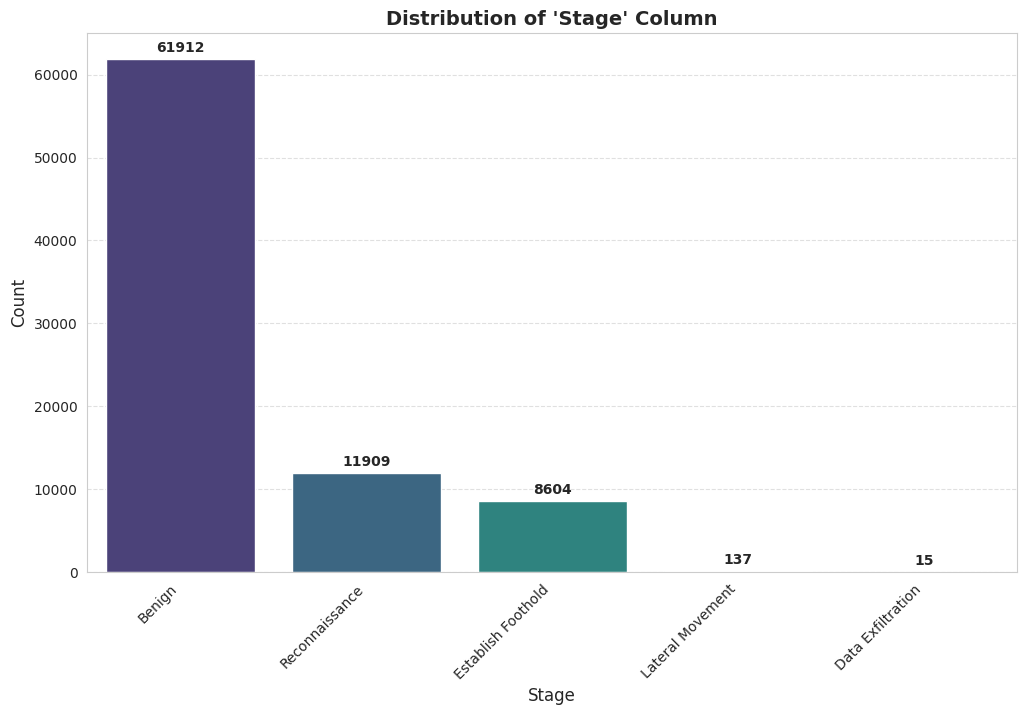


>> Visualization Complete. Proceeding to the next step.



In [7]:
# Step 3: Visualizing the Distribution of the Stage Column
print("\n" + "="*60)
print(">> Step 3: Visualizing the Distribution of the 'Stage' Column")
print("="*60 + "\n")

# Display unique stage categories and their counts
stage_counts = df["Stage"].value_counts()
total_entries = df.shape[0]

print(df.shape[0])

print(">> Unique Stages Found in Dataset:")
for stage, count in stage_counts.items():
    percentage = (count / total_entries) * 100
    print(f"   - {stage}: {count} instances ({percentage:.2f}%)")

# Plot the distribution of the "Stage" column
plt.figure(figsize=(12, 7))
sns.countplot(x=df["Stage"], order=stage_counts.index, palette="viridis")
plt.title("Distribution of 'Stage' Column", fontsize=14, fontweight="bold")
plt.xlabel("Stage", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Show exact counts on the bars
for index, value in enumerate(stage_counts):
    plt.text(index, value + (0.01 * total_entries), str(value), ha="center", fontsize=10, fontweight="bold")

# Display the plot
plt.show()

print("\n>> Visualization Complete. Proceeding to the next step.\n")
print("="*60)


In [8]:
df.head()

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Activity,Stage
0,0,0,0,119998944,242,1,0,0,0,0,...,0.0,0.0,0,0,0.0,0.0,0,0,Normal,Benign
1,53569,8662,17,109235816,21,1,1072,52,56,48,...,819535.5,78517.84409,875056,764015,15175318.571429,6349189.183744,20019201,5202524,Normal,Benign
2,68,67,17,119764062,88,1,25515,289,296,288,...,0.0,0.0,0,0,0.0,0.0,0,0,Normal,Benign
3,40504,9200,6,117030424,18,17,23499,3736,4096,0,...,192329.333333,436593.123269,1083374,7236,19311305.166667,11778304.083737,34978598,5147962,Normal,Benign
4,0,0,0,119999703,2,1,0,0,0,0,...,0.0,0.0,0,0,59999851.5,847.821031,60000451,59999252,Normal,Benign


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86690 entries, 0 to 86689
Data columns (total 81 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Src Port                    82577 non-null  Int64  
 1   Dst Port                    82577 non-null  Int64  
 2   Protocol                    82577 non-null  Int64  
 3   Flow Duration               82577 non-null  Int64  
 4   Total Fwd Packet            82577 non-null  Int64  
 5   Total Bwd packets           82577 non-null  Int64  
 6   Total Length of Fwd Packet  82577 non-null  Int64  
 7   Total Length of Bwd Packet  82577 non-null  Int64  
 8   Fwd Packet Length Max       82577 non-null  Int64  
 9   Fwd Packet Length Min       82577 non-null  Int64  
 10  Fwd Packet Length Mean      82577 non-null  Float64
 11  Fwd Packet Length Std       82577 non-null  Float64
 12  Bwd Packet Length Max       82577 non-null  Int64  
 13  Bwd Packet Length Min       825

In [10]:
df.describe()

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,82577.0,82577.0,82577.0,82577.0,82577.0,82577.0,82577.0,82577.0,82577.0,82577.0,...,82577.0,82577.0,82577.0,82577.0,82577.0,82577.0,82577.0,82577.0,82577.0,82577.0
mean,39894.20961,8138.424925,9.146082,20524170.842765,56.409606,80.873415,20304.431222,43224.263257,226.423605,21.675358,...,14.99145,0.0,585318.294476,242589.082754,860616.866912,349452.429647,3826880.608694,629080.867621,4525702.724524,3217836.93256
std,18883.995405,14065.843842,5.461515,41495411.04868,2572.795881,5146.954432,1900679.511418,823080.801009,935.45289,89.288104,...,241.503525,0.0,2978021.88663,1271590.668457,3829861.733761,2240448.529062,11282273.179053,2737022.323168,12620601.73178,10639227.158644
min,0.0,0.0,0.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,36218.0,53.0,6.0,426.0,1.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,47232.0,445.0,6.0,15783.0,1.0,3.0,45.0,228.0,45.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,53141.0,9002.0,17.0,2116769.0,8.0,5.0,602.0,489.0,122.0,45.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,65475.0,65432.0,17.0,119999997.0,259089.0,518384.0,253467291.0,95483154.0,64440.0,11584.0,...,58252.0,0.0,93131435.0,56605618.931889,93131435.0,93131435.0,119756900.0,61462509.137689,119756900.0,119756900.0


In [11]:
# Check for missing values
print("\n>> Step 2: Checking and Handling Missing Values...")

# Count missing values per column
missing_counts = df.isnull().sum()
total_missing = missing_counts.sum()

# Display missing values info
if total_missing > 0:
    print(f">> Warning: Dataset contains {total_missing} missing values across {missing_counts[missing_counts > 0].count()} columns.")
    print("\n>> Missing Value Breakdown (Columns with Missing Data):")
    print(missing_counts[missing_counts > 0])
else:
    print(">> No missing values detected in the dataset.")

# Print shape before dropping missing values
print(f">> Initial Dataset Shape: {df.shape}")

# Drop missing values
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)  # Reset index after dropping rows

# Print shape after handling missing values
print("\n>> Missing values handled. Rows with missing values removed!")
print(f">> Updated Dataset Shape: {df.shape}")

# Verify if missing values exist after cleaning
remaining_missing = df.isnull().sum().sum()
if remaining_missing == 0:
    print(">> Dataset is now clean, with no missing values.")
else:
    print(f">> Caution: {remaining_missing} missing values still remain. Further cleaning may be required.")



>> Step 2: Checking and Handling Missing Values...
>> Warning: Dataset contains 333153 missing values across 81 columns.

>> Missing Value Breakdown (Columns with Missing Data):
Src Port            4113
Dst Port            4113
Protocol            4113
Flow Duration       4113
Total Fwd Packet    4113
                    ... 
Idle Std            4113
Idle Max            4113
Idle Min            4113
Activity            4113
Stage               4113
Length: 81, dtype: int64
>> Initial Dataset Shape: (86690, 81)

>> Missing values handled. Rows with missing values removed!
>> Updated Dataset Shape: (82577, 81)
>> Dataset is now clean, with no missing values.


In [12]:
# Step 2: Checking for Missing Values
print("\n" + "="*50)
print(">> Step 2: Checking and Handling Missing Values...")
print("="*50 + "\n")

# Compute missing values for each column
missing_counts = df.isnull().sum()
total_missing = missing_counts.sum()

# Display summary of missing values
print(f">> Total Missing Values in Dataset: {total_missing}")
if total_missing > 0:
    print(f">> Affected Columns: {missing_counts[missing_counts > 0].count()}")
    print("\n>> Missing Value Breakdown (Columns with Missing Data):")
    print(missing_counts[missing_counts > 0])
else:
    print(">> No missing values detected in the dataset. Proceeding with next steps.")

# Print dataset shape before cleaning
print("\n>> Dataset Shape Before Cleaning: Rows = {}, Columns = {}".format(*df.shape))

# Drop missing values
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)  # Reset index to maintain structure

# Print dataset shape after cleaning
print("\n>> Missing values removed successfully!")
print(">> Updated Dataset Shape: Rows = {}, Columns = {}".format(*df.shape))

# Final verification for any remaining missing values
remaining_missing = df.isnull().sum().sum()
if remaining_missing == 0:
    print("\n>> Data Cleaning Complete! No Missing Values Remain.")
else:
    print(f"\n>> Warning: {remaining_missing} missing values still present. Further cleaning required.")

print("\n" + "="*50)


>> Step 2: Checking and Handling Missing Values...

>> Total Missing Values in Dataset: 0
>> No missing values detected in the dataset. Proceeding with next steps.

>> Dataset Shape Before Cleaning: Rows = 82577, Columns = 81

>> Missing values removed successfully!
>> Updated Dataset Shape: Rows = 82577, Columns = 81

>> Data Cleaning Complete! No Missing Values Remain.




>> Step 3: Visualizing the Distribution of the 'Stage' Column

>> Unique Stages Found in Dataset:
   - Benign: 61912 instances (74.97%)
   - Reconnaissance: 11909 instances (14.42%)
   - Establish Foothold: 8604 instances (10.42%)
   - Lateral Movement: 137 instances (0.17%)
   - Data Exfiltration: 15 instances (0.02%)


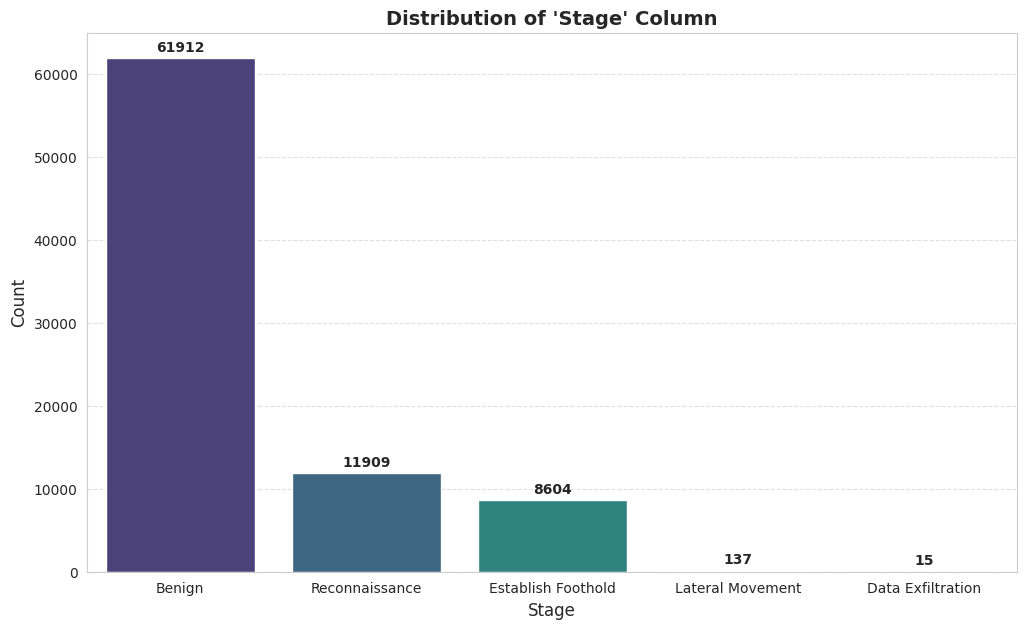


>> Visualization Complete. Proceeding to the next step.



In [22]:
# Step 3: Visualizing the Distribution of the Stage Column
print("\n" + "="*60)
print(">> Step 3: Visualizing the Distribution of the 'Stage' Column")
print("="*60 + "\n")

# Display unique stage categories and their counts
stage_counts = df["Stage"].value_counts()
total_entries = df.shape[0]

print(">> Unique Stages Found in Dataset:")
for stage, count in stage_counts.items():
    percentage = (count / total_entries) * 100
    print(f"   - {stage}: {count} instances ({percentage:.2f}%)")

# Plot the distribution of the "Stage" column
plt.figure(figsize=(12, 7))
sns.countplot(x=df["Stage"], order=stage_counts.index, palette="viridis")
plt.title("Distribution of 'Stage' Column", fontsize=14, fontweight="bold")
plt.xlabel("Stage", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0, ha="center", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Show exact counts on the bars
for index, value in enumerate(stage_counts):
    plt.text(index, value + (0.01 * total_entries), str(value), ha="center", fontsize=10, fontweight="bold")

# Display the plot
plt.show()

print("\n>> Visualization Complete. Proceeding to the next step.\n")
print("="*60)


In [14]:
# Step 4: Printing and Analyzing the Distribution of the Stage Column
print("\n" + "="*60)
print(">> Step 4: Analyzing the Distribution of the 'Stage' Column")
print("="*60 + "\n")

# Calculate and display distribution
stage_counts = df["Stage"].value_counts()
stage_percentages = (stage_counts / df.shape[0]) * 100  # Convert counts to percentages

# Print formatted distribution
print(">> Distribution of 'Stage' Column:\n")
for stage, count in stage_counts.items():
    percentage = stage_percentages[stage]
    print(f"   - {stage}: {count} instances ({percentage:.2f}%)")

# Display summary statistics
print("\n>> Summary:")
print(f"   - Total Instances: {df.shape[0]}")
print(f"   - Unique Stages: {df['Stage'].nunique()}")

print("\n>> Stage Distribution Analysis Complete.\n")
print("="*60)



>> Step 4: Analyzing the Distribution of the 'Stage' Column

>> Distribution of 'Stage' Column:

   - Benign: 61912 instances (74.97%)
   - Reconnaissance: 11909 instances (14.42%)
   - Establish Foothold: 8604 instances (10.42%)
   - Lateral Movement: 137 instances (0.17%)
   - Data Exfiltration: 15 instances (0.02%)

>> Summary:
   - Total Instances: 82577
   - Unique Stages: 5

>> Stage Distribution Analysis Complete.



In [15]:
# Step 5: Creating Label Columns for Classification
print("\n" + "="*60)
print(">> Step 5: Creating Label Columns for Classification")
print("="*60 + "\n")

# Generate binary labels: 0 for Benign, 1 for other attack types
df["Binary_Label"] = df["Stage"].apply(lambda x: 0 if x == "Benign" else 1)

# Display label distribution
label_counts = df["Binary_Label"].value_counts()
label_percentages = (label_counts / df.shape[0]) * 100  # Convert counts to percentages

# Print formatted distribution
print(">> Binary Label Distribution:\n")
for label, count in label_counts.items():
    label_name = "Benign" if label == 0 else "Attack"
    percentage = label_percentages[label]
    print(f"   - {label_name}: {count} instances ({percentage:.2f}%)")

# Summary
print("\n>> Summary:")
print(f"   - Total Instances: {df.shape[0]}")
print(f"   - Unique Binary Labels: {df['Binary_Label'].nunique()}")

# Validate correctness of labeling
print("\n>> Binary Labeling Process Completed Successfully.\n")
print("="*60)



>> Step 5: Creating Label Columns for Classification

>> Binary Label Distribution:

   - Benign: 61912 instances (74.97%)
   - Attack: 20665 instances (25.03%)

>> Summary:
   - Total Instances: 82577
   - Unique Binary Labels: 2

>> Binary Labeling Process Completed Successfully.



In [16]:
# Step 6: Creating Multiclass Labels for Classification
print("\n" + "="*60)
print(">> Step 6: Creating Multiclass Labels for Classification")
print("="*60 + "\n")

# Define the multiclass mapping dictionary
multiclass_mapping = {
    "Benign": 0, 
    "Reconnaissance": 1, 
    "Establish Foothold": 2,
    "Lateral Movement": 3, 
    "Data Exfiltration": 4
}

# Map the "Stage" column to create numerical multiclass labels
df["Multiclass_Label"] = df["Stage"].map(multiclass_mapping)

# Validate mapping and display label distribution
multiclass_counts = df["Multiclass_Label"].value_counts().sort_index()
multiclass_percentages = (multiclass_counts / df.shape[0]) * 100  # Convert to percentages

# Print formatted distribution details
print(">> Multiclass Label Distribution:\n")
for label, count in multiclass_counts.items():
    stage_name = [k for k, v in multiclass_mapping.items() if v == label][0]
    percentage = multiclass_percentages[label]
    print(f"   - {stage_name} (Label {label}): {count} instances ({percentage:.2f}%)")

# Summary of the dataset after labeling
print("\n>> Summary:")
print(f"   - Total Instances: {df.shape[0]}")
print(f"   - Unique Multiclass Labels: {df['Multiclass_Label'].nunique()}")

# Validate correctness of mapping
if df["Multiclass_Label"].isnull().sum() == 0:
    print("\n>> Multiclass Labeling Process Completed Successfully.\n")
else:
    print("\n>> Warning: Some instances could not be mapped. Check for missing values.\n")

print("="*60)



>> Step 6: Creating Multiclass Labels for Classification

>> Multiclass Label Distribution:

   - Benign (Label 0): 61912 instances (74.97%)
   - Reconnaissance (Label 1): 11909 instances (14.42%)
   - Establish Foothold (Label 2): 8604 instances (10.42%)
   - Lateral Movement (Label 3): 137 instances (0.17%)
   - Data Exfiltration (Label 4): 15 instances (0.02%)

>> Summary:
   - Total Instances: 82577
   - Unique Multiclass Labels: 5

>> Multiclass Labeling Process Completed Successfully.




>> Step 7: Visualizing Label Distributions



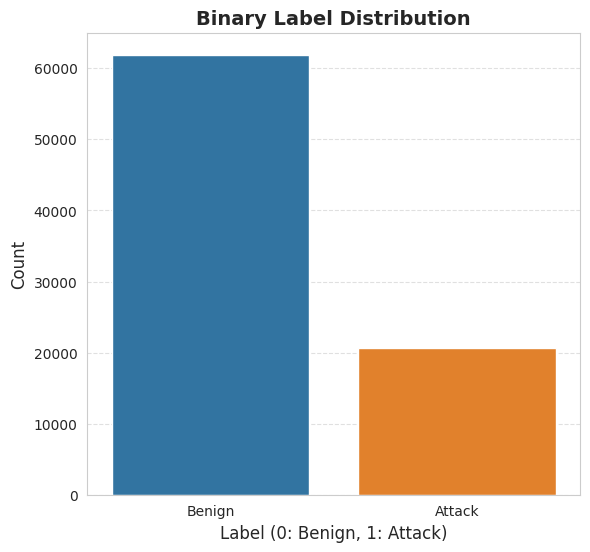

In [17]:
# Step 7: Visualizing the Label Distributions
print("\n" + "="*60)
print(">> Step 7: Visualizing Label Distributions")
print("="*60 + "\n")

# Define figure size and layout
plt.figure(figsize=(14, 6))

# Plot Binary Label Distribution
plt.subplot(1, 2, 1)
sns.countplot(x=df["Binary_Label"], palette=["#1f77b4", "#ff7f0e"])
plt.title("Binary Label Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Label (0: Benign, 1: Attack)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(ticks=[0, 1], labels=["Benign", "Attack"])
plt.grid(axis="y", linestyle="--", alpha=0.6)

print("="*60)


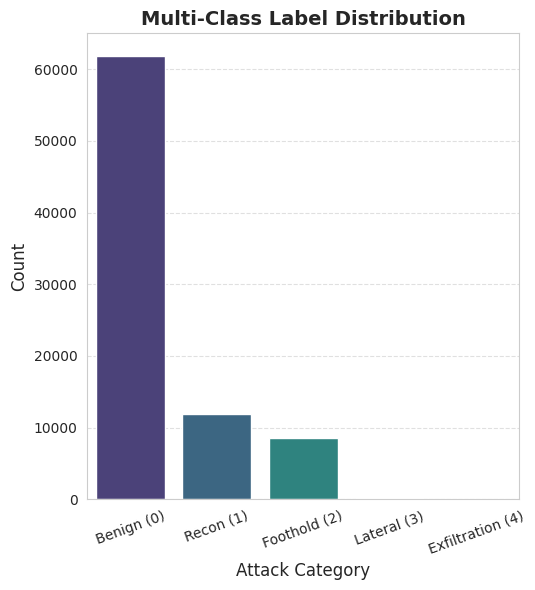

In [18]:
# Plot Multi-Class Label Distribution
plt.subplot(1, 2, 2)
sns.countplot(x=df["Multiclass_Label"], palette="viridis")
plt.title("Multi-Class Label Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Attack Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(ticks=range(5), labels=[
    "Benign (0)", "Recon (1)", "Foothold (2)", "Lateral (3)", "Exfiltration (4)"
], rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

In [17]:
# Display numerical distribution details
print(">> Binary Label Distribution:\n", df["Binary_Label"].value_counts(), "\n")
print(">> Multi-Class Label Distribution:\n", df["Multiclass_Label"].value_counts(), "\n")

>> Binary Label Distribution:
 Binary_Label
0    61912
1    20665
Name: count, dtype: int64 

>> Multi-Class Label Distribution:
 Multiclass_Label
0    61912
1    11909
2     8604
3      137
4       15
Name: count, dtype: int64 



In [18]:
# Step 9: Defining Safe Mathematical Operations
@jit(nopython=True)
def safeDiv(a: float, b: float) -> float:
    """
    Safely performs division while avoiding division-by-zero errors.
    
    Parameters:
    a (float): Numerator
    b (float): Denominator
    
    Returns:
    float: The result of a / b if b is nonzero; otherwise, returns 1.
    """
    return a / b if b != 0 else 1  # Prevents division by zero

In [19]:
# Step 10: Defining Custom Operators and Classification Functions

# Classification function based on fixed thresholds (Algorithm 1)
def classify_output(y_pred, mode="binary"):
    """
    Classifies predictions based on different modes: binary, multiclass.

    Parameters:
    y_pred (numpy array): Array of predicted values.
    mode (str): Classification mode - "binary", "multiclass".

    Returns:
    numpy array: Classified output labels based on thresholds.
    """
    y_pred = np.clip(y_pred, -1, 1)  # Clip values to prevent overflow in sigmoid
    y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))  # Sigmoid function for normalization

    if mode == "binary":
        return (y_pred_sigmoid > 0.5).astype(int)  # Binary classification threshold

    elif mode == "multiclass":
        thresholds = [0.20, 0.40, 0.60, 0.80]  # Multi-class thresholds
        return np.digitize(y_pred_sigmoid, bins=thresholds)  # Assign classes based on thresholds

    else:
        raise ValueError(f"Invalid classification mode: {mode}. Choose 'binary', 'multiclass'.")

In [20]:
from sklearn.utils.class_weight import compute_class_weight

# GP evaluation function following Algorithm 1
def evalGP(individual, X_train, y_train, mode):
    """
    Evaluates a Genetic Programming (GP) individual on the training data.

    Parameters:
    individual (gp.PrimitiveTree): GP tree representing an evolved function.
    X_train (numpy array): Feature matrix for training.
    y_train (numpy array): Target labels for training.
    mode (str): Classification mode - "binary" or "multiclass".

    Returns:
    tuple: Fitness score (balanced accuracy).
    """

    # Compile GP tree into a function f(x)
    func = gp.compile(expr=individual, pset=pset)

    # Apply the evolved function to each sample in the training set
    y_pred = np.apply_along_axis(lambda x: func(*x), axis=1, arr=X_train)

    # Clip predictions to prevent extreme values affecting sigmoid
    y_pred = np.clip(y_pred, -1, 1)

    # Apply sigmoid transformation to normalize predictions
    y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))

    # Classify outputs based on the selected mode
    y_pred_class = np.array([classify_output(val, mode) for val in y_pred_sigmoid])

    # Ensure predictions match valid class labels
    valid_classes = np.unique(y_train)  # Extract valid class labels from training data
    y_pred_class = np.array([
        c if c in valid_classes else np.random.choice(valid_classes)
        for c in y_pred_class
    ])

    # Compute class weights to handle class imbalance
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=valid_classes,
        y=y_train
    )
    weights_dict = {cls: weight for cls, weight in zip(valid_classes, class_weights)}

    # Calculate weighted balanced accuracy
    sample_weights = np.array([weights_dict[y] for y in y_train])
    fitness = balanced_accuracy_score(y_train, y_pred_class, sample_weight=sample_weights)

    return (fitness,)


In [21]:
from deap import tools
import numpy as np
import random

def run_gp(X_train, y_train, mode, population_size=256, ngen=50, cxpb=0.8, mutpb=0.19):
    """
    Runs the Genetic Programming (GP) evolution process.

    Parameters:
    X_train (numpy array): Feature matrix for training.
    y_train (numpy array): Target labels for training.
    mode (str): Classification mode ("binary" or "multiclass").
    population_size (int): Number of individuals in the population.
    ngen (int): Number of generations to evolve.
    cxpb (float): Probability of applying crossover.
    mutpb (float): Probability of applying mutation.

    Returns:
    tuple: Best individual from the evolution and recorded statistics.
    """

    print(f"\n>> Starting GP Evolution for {mode.upper()} Classification...\n")

    # Initialize population and hall of fame
    pop = toolbox.population(n=population_size)
    hof = tools.HallOfFame(1)  # Track the best individual

    # Track stats
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # Evaluate initial population
    print(">>> Evaluating Initial Population...")
    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    # Evolutionary process
    for gen in range(1, ngen + 1):
        print(f"\n>>> Generation {gen}/{ngen}")

        # Selection (Elitism: keep the best individual)
        offspring = toolbox.select(pop, len(pop))
        offspring = list(map(toolbox.clone, offspring))

        # Apply Crossover
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(child1, child2)
                del child1.fitness.values, child2.fitness.values
        print(">>> Crossover Applied")

        # Apply Mutation
        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values
        print(">>> Mutation Applied")

        # Evaluate new individuals
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = list(map(toolbox.evaluate, invalid_ind))
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Replace old population with offspring
        pop[:] = offspring

        # Track the best individual
        hof.update(pop)  
        best_ind = hof[0]

    print("\n>> Evolution Completed!")

    # Print final best individual
    best_individual = hof[0]

    return best_individual, stats


In [22]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", figsize=(6, 5), normalize=False):
    """
    Plots a confusion matrix using seaborn.

    Parameters:
    y_true (array-like): True labels.
    y_pred (array-like): Predicted labels.
    title (str): Title of the confusion matrix plot.
    figsize (tuple): Figure size for the plot.
    normalize (bool): If True, normalizes the confusion matrix.
    """

    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
    else:
        fmt = "d"

    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()


In [23]:
from sklearn.metrics import classification_report, balanced_accuracy_score

def evaluate_best_model(best_individual, X_test, y_test, mode):
    """
    Evaluates the best GP individual on the test dataset and plots the confusion matrix.

    Parameters:
    - best_individual: The best-evolved genetic programming model.
    - X_test (array-like): Test features.
    - y_test (array-like): True labels for test data.
    - mode (str): Classification mode ("binary" or "multiclass").

    Returns:
    - acc (float): Balanced accuracy score.
    """
    # Compile GP tree into an executable function
    func = gp.compile(expr=best_individual, pset=pset)

    # Apply the function to the test data
    y_pred = np.apply_along_axis(lambda x: func(*x), 1, X_test)

    # Clipping and sigmoid transformation
    y_pred = np.clip(y_pred, -1, 1)
    y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))

    # Convert predictions to class labels
    y_pred_class = np.array([classify_output(val, mode) for val in y_pred_sigmoid])

    # Compute balanced accuracy
    acc = balanced_accuracy_score(y_test, y_pred_class)
    
    # Print evaluation metrics
    print("\n>> Classification Report:")
    print(classification_report(y_test, y_pred_class, digits=4))

    # Plot confusion matrix
    plot_confusion_matrix(y_test, y_pred_class, title=f"Confusion Matrix ({mode})")

    return acc


In [24]:
def plot_evolution(stats, title="Evolution Progress"):
    """
    Plots the evolution progress of genetic programming over generations.

    Parameters:
    - stats: DEAP Statistics object containing fitness values.
    - title (str): Title of the plot.

    Returns:
    - None (Displays the plot)
    """
    # Extract generation count
    generations = list(range(len(stats)))

    # Extract average and max accuracy from stats
    avg_acc = stats.select("avg")
    max_acc = stats.select("max")

    # Plot evolution trends
    plt.figure(figsize=(10, 5))
    plt.plot(generations, avg_acc, label="Average Fitness", linestyle="--", marker="o", color="b")
    plt.plot(generations, max_acc, label="Max Fitness", marker="s", color="g")

    # Graph labels and formatting
    plt.xlabel("Generation")
    plt.ylabel("Balanced Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    
    # Show final value annotations
    plt.annotate(f"{avg_acc[-1]:.4f}", (generations[-1], avg_acc[-1]), textcoords="offset points", xytext=(-10,5), ha='center', fontsize=10, color="b")
    plt.annotate(f"{max_acc[-1]:.4f}", (generations[-1], max_acc[-1]), textcoords="offset points", xytext=(-10,-15), ha='center', fontsize=10, color="g")
    
    plt.show()


In [25]:
import time

# Simple alert system for multistage classification
def alert_system(best_individual, X_test, model):
    """
    Runs a real-time attack detection alert system using the best GP model.

    Parameters:
    - best_individual: The evolved genetic programming model.
    - X_test: The test dataset for evaluation.

    Returns:
    - None (Prints real-time alerts).
    """
    func = gp.compile(expr=best_individual, pset=pset)
    
    # Predict classes using best GP model
    y_pred = np.apply_along_axis(lambda x: func(*x), 1, X_test)
    
    # Apply sigmoid transformation
    y_pred = np.clip(y_pred, -1, 1)
    y_pred_sigmoid = 1.0 / (1.0 + np.exp(-y_pred))
    
    # Classify outputs into multistage categories
    y_pred_class = np.array([classify_output(val, model) for val in y_pred_sigmoid])
    
    # Define alert messages
    alert_labels = {
        0: "Normal Traffic",
        1: "Reconnaissance Detected!",
        2: "Foothold Establishment / Lateral Movement Detected!",
        3: "Data Exfiltration Detected! Possible Breach!"
    }
    
    print("\n🔍 Real-Time Attack Detection Alerts (first 10 instances):\n")
    
    # Print alerts only for anomalies (not normal traffic)
    for i, cls in enumerate(y_pred_class[:10]):
        timestamp = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())
        alert_msg = alert_labels.get(cls, "❓ Unknown Threat Level")
        
        if cls != 0:  # Skip normal traffic if needed
            print(f"[{timestamp}] Alert {i+1}: {alert_msg}")


In [26]:
# Select numeric feature columns
feature_cols = [col for col in df.columns if col not in ["Stage", "Binary_Label", "Multiclass_Label"]]
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")
df.fillna(0, inplace=True)
X = df[feature_cols].values.astype(float)
print(f">> Feature Extraction Completed! Number of Features: {len(feature_cols)}")

X.shape

>> Feature Extraction Completed! Number of Features: 80


(82577, 80)

In [27]:
# Check for NaN values before scaling
if np.isnan(X).sum() > 0:
    print(">> Warning: NaN values detected! Filling with median before scaling.")
    X = np.nan_to_num(X, nan=np.median(X, axis=0))

# Initialize RobustScaler
scaler = MinMaxScaler()

# Fit on training data & transform
X = scaler.fit_transform(X)

print(">> Normalization Completed!")



>> Normalizing Features Using RobustScaler...
>> Normalization Completed!


In [28]:
X_df = pd.DataFrame(X)
X_df.head()

,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
0,0.000000,0.000000,0.000000,0.999991,0.000934,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,0.818160,0.132382,1.000000,0.910298,0.000081,0.000000,0.000004,5.445987e-07,0.000869,0.004144,...,0.0,0.008800,0.001387,0.009396,0.008204,0.126718,0.103302,0.167165,0.043442,0.0
2,0.001039,0.001024,1.000000,0.998034,0.000340,0.000000,0.000101,3.026712e-06,0.004593,0.024862,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,0.618618,0.140604,0.352941,0.975254,0.000069,0.000031,0.000093,3.912732e-05,0.063563,0.000000,...,0.0,0.002065,0.007713,0.011633,0.000078,0.161254,0.191634,0.292080,0.042987,0.0
4,0.000000,0.000000,0.000000,0.999998,0.000008,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.501014,0.000014,0.501019,0.501009,0.0


In [29]:
from sklearn.model_selection import train_test_split

print("\n>> Splitting Data into Training and Test Sets...")

# Split data while ensuring stratification for both labels
X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X, 
    df["Binary_Label"].values, 
    df["Multiclass_Label"].values, 
    test_size=0.2, 
    stratify=df["Multiclass_Label"],  # Ensures balanced class distribution in train/test
    random_state=42
)

print(f">> Data Splitting Completed! Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")



>> Splitting Data into Training and Test Sets...
>> Data Splitting Completed! Train Shape: (66061, 80), Test Shape: (16516, 80)


In [30]:
# Count occurrences of each class in y_test_bin and y_test_multi
from collections import Counter

# Count labels in binary classification test set
bin_counts = Counter(y_test_bin)

# Count labels in multi-class classification test set
multi_counts = Counter(y_test_multi)

bin_counts, multi_counts


(Counter({np.int64(0): 12383, np.int64(1): 4133}),
 Counter({np.int64(0): 12383,
          np.int64(1): 2382,
          np.int64(2): 1721,
          np.int64(3): 27,
          np.int64(4): 3}))

In [31]:
import operator
import numpy as np
import deap.gp as gp
from deap import creator, base, tools

print("\n>> Step 2: Setting Up Genetic Programming (GP) with DEAP...\n")

# Define Primitive Set
pset = gp.PrimitiveSet("MAIN", X_train.shape[1])

# Basic Operators
pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)
pset.addPrimitive(safeDiv, 2)

# Max & Min Functions
pset.addPrimitive(np.maximum, 2, name="max")
pset.addPrimitive(np.minimum, 2, name="min")

# Sanitize feature names: Replace spaces and special characters
sanitized_feature_cols = {col: f"feature_{i}" for i, col in enumerate(feature_cols)}

# Apply sanitized names to the GP primitive set
pset.renameArguments(**sanitized_feature_cols)

print(">> GP Primitive Set Successfully Configured!")

# Ensure previous DEAP classes are removed before redefianing them
if hasattr(creator, "FitnessMax"):
    del creator.FitnessMax
if hasattr(creator, "Individual"):
    del creator.Individual

# Define Fitness & Individual
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

# Define Toolbox
toolbox = base.Toolbox()
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=2, max_=6)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr, pset=pset)
toolbox.register("select", tools.selTournament, tournsize=7)


print(">> GP Toolbox Successfully Configured!")



>> Step 2: Setting Up Genetic Programming (GP) with DEAP...

>> GP Primitive Set Successfully Configured!
>> GP Toolbox Successfully Configured!


In [44]:
import functools

print("\n>> Running GP Evolution for Binary Classification...")

# Unregister evaluate if already registered (to avoid duplicate registrations)
if "evaluate" in toolbox.__dict__:
    del toolbox.__dict__["evaluate"]

# Register the evaluate function with required arguments using functools.partial
toolbox.register("evaluate", functools.partial(evalGP, X_train=X_train, y_train=y_train_bin, mode="binary"))

# Run Genetic Programming for Binary Classification
best_binary, stats_binary = run_gp(X_train, y_train_bin, mode="binary")

print("\n>> Best GP Individual for Binary Classification:")
print(best_binary)



>> Running GP Evolution for Binary Classification...

>> Starting GP Evolution for BINARY Classification...

>>> Evaluating Initial Population...

>>> Generation 1/50
>>> Crossover Applied
>>> Mutation Applied

>>> Generation 2/50
>>> Crossover Applied
>>> Mutation Applied

>>> Generation 3/50
>>> Crossover Applied
>>> Mutation Applied

>>> Generation 4/50
>>> Crossover Applied
>>> Mutation Applied

>>> Generation 5/50
>>> Crossover Applied
>>> Mutation Applied

>>> Generation 6/50
>>> Crossover Applied
>>> Mutation Applied

>>> Generation 7/50
>>> Crossover Applied
>>> Mutation Applied

>>> Generation 8/50
>>> Crossover Applied
>>> Mutation Applied

>>> Generation 9/50
>>> Crossover Applied
>>> Mutation Applied

>>> Generation 10/50
>>> Crossover Applied
>>> Mutation Applied

>>> Generation 11/50
>>> Crossover Applied
>>> Mutation Applied

>>> Generation 12/50
>>> Crossover Applied
>>> Mutation Applied

>>> Generation 13/50
>>> Crossover Applied
>>> Mutation Applied

>>> Generation 1


>> Step 4: Evaluating the Evolved Models on Test Data...


>> Evaluating Multi-class Classification Model...


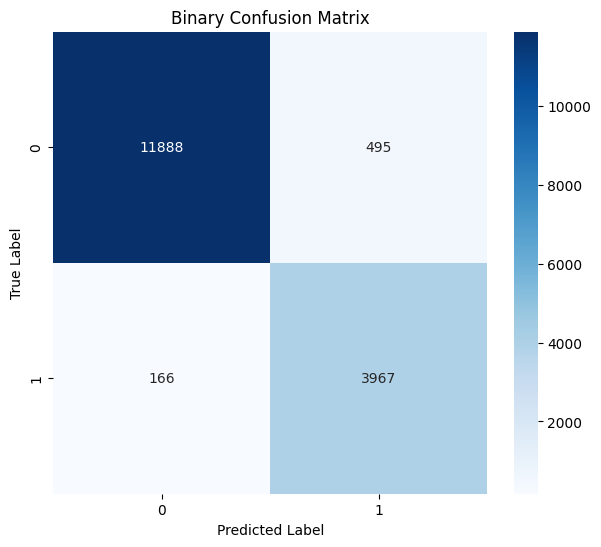

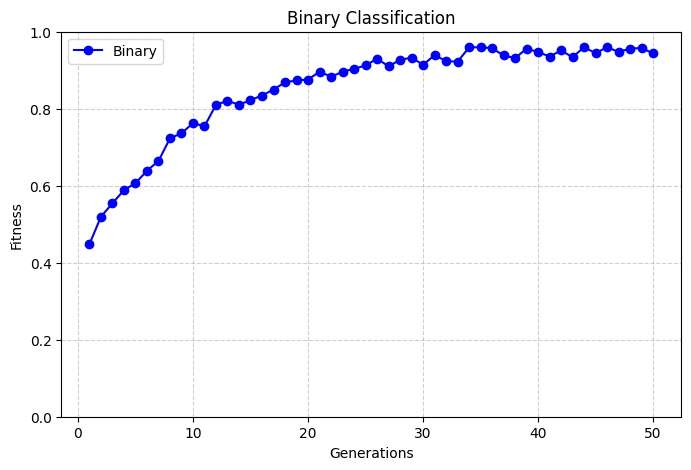


>> Binary Model Accuracy: 96.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97     12383
           1       0.89      0.96      0.92      4133

    accuracy                           0.96     16516
   macro avg       0.94      0.96      0.95     16516
weighted avg       0.96      0.96      0.96     16516



In [3]:
print("\n>> Step 4: Evaluating the Evolved Models on Test Data...\n")

if best_binary:
    print("\n>> Evaluating Multi-class Classification Model...")
    cm_binary, report_binary = _deap.evaluate_best_Model(best_binary, X_test, y_test_bin, "binary")
    acc_binary = np.trace(cm_binary) / np.sum(cm_binary)
    print(f"\n>> Binary Model Accuracy: {acc_binary:.2%}")
    print("\nClassification Report:\n", report_binary)
else:
    print("No valid multi-class classification model found!")